# Trading Behavior Anomaly Detection

We aim to detect abnormal trading behavior patterns using unsupervised learning.

This system analyzes user-level trading activity to identify accounts that deviate significantly from normal behavioral patterns.

In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from src.ingestion.loader import load_raw_data

df = load_raw_data(Path("../data/raw/historical_data.csv"))
df.shape

[INFO] 2026-04-24 21:19:19,995 | src.ingestion.loader | Loading raw data from: ../data/raw/historical_data.csv
[INFO] 2026-04-24 21:19:20,423 | src.ingestion.loader | Data loaded: shape=(211224, 16)


(211224, 16)

In [5]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Dataset contains transactional-level trading activity aggregated into user-day behavioral features.

We engineered the following behavioral features:

- trades_per_day
- total_trade_volume_per_day
- avg_trade_size
- avg_time_between_trades

In [6]:
from src.preprocessing.preprocess_trades import preprocess_trading_data
features = preprocess_trading_data(df)
features

[INFO] 2026-04-24 21:19:22,264 | src.preprocessing.preprocess_trades | Starting preprocessing
[INFO] 2026-04-24 21:19:22,355 | src.preprocessing.preprocess_trades | Aggregated features shape: (102, 5)
[INFO] 2026-04-24 21:19:22,443 | src.preprocessing.preprocess_trades | Preprocessing completed


,Account,date,trades_per_day,total_trade_volume_per_day,avg_trade_size,avg_time_between_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462,6842632.02,14810.891818,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356,54854631.95,16345.241940,2979.737783
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320,797679.97,2492.749906,0.000000
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533,5982611.50,1693.351684,2830.455703
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427,5255196.19,1533.468395,2918.004085
...,...,...,...,...,...,...
97,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-02-19,2211,17917884.11,8103.972913,4522.840344
98,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-06-15,163,2091724.18,12832.663681,61349.693252
99,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2024-10-27,9883,26617723.76,2693.283796,0.000000
100,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-02-19,26651,41437969.80,1554.837334,375.220442


We used Isolation Forest for unsupervised anomaly detection.

It isolates anomalous behavior by recursively partitioning feature space.

In [7]:
from src.modeling.train import train_model
model, scaler = train_model(features)

[INFO] 2026-04-24 21:19:23,404 | src.modeling.train | Starting model training
[INFO] 2026-04-24 21:19:23,557 | src.modeling.train | Model + scaler saved to artifacts/


In [9]:
from src.modeling.predict import predict_anomalies
results = predict_anomalies(model, scaler, features)

## Anomaly Score Distribution

We visualize how anomaly scores are distributed across the dataset.

Lower scores indicate more anomalous observations.

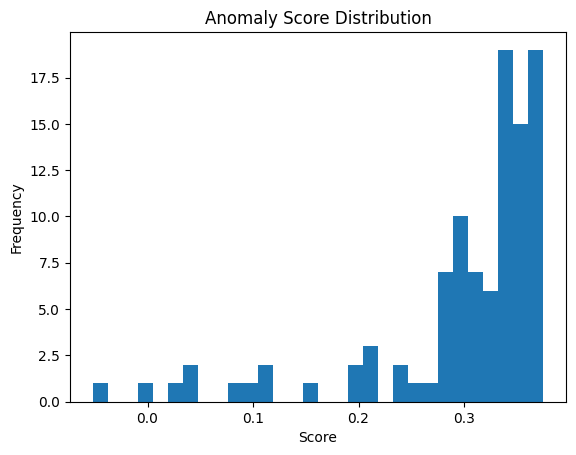

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(results["anomaly_score"], bins=30)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

### Interpretation

Most observations cluster around higher scores, representing normal behavior.

A small left-tail corresponds to anomalous points that are significantly different from the majority.

## Feature Distribution: Normal vs Anomalies

We compare key behavioral features across:
- Normal users
- Anomalous users

This helps identify what drives anomaly detection.

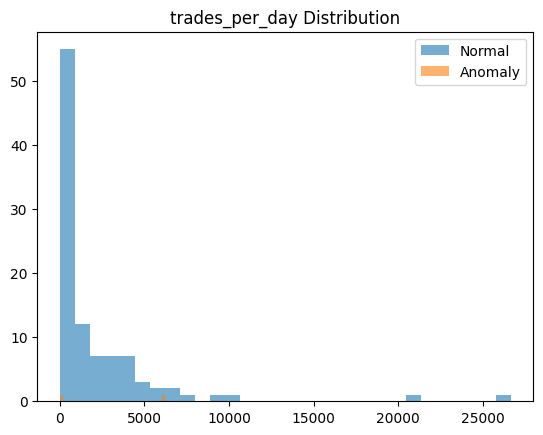

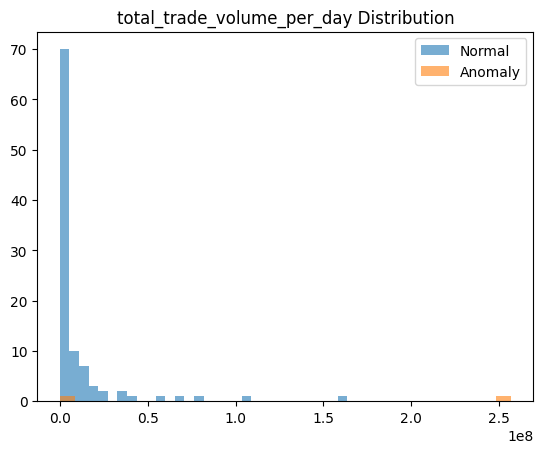

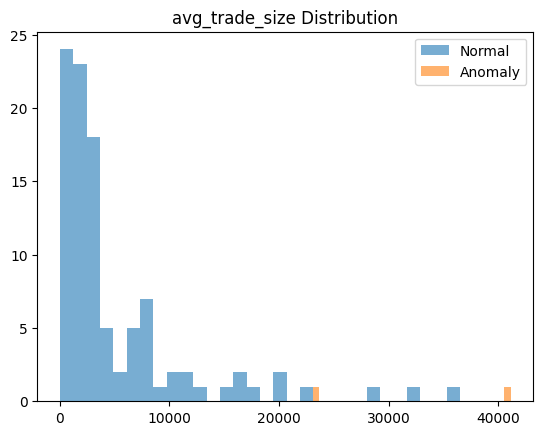

In [18]:
import matplotlib.pyplot as plt

for col in ["trades_per_day", "total_trade_volume_per_day", "avg_trade_size"]:
    plt.figure()
    
    plt.hist(results[results["is_anomaly"] == 0][col], bins=30, alpha=0.6, label="Normal")
    plt.hist(results[results["is_anomaly"] == 1][col], bins=30, alpha=0.6, label="Anomaly")
    
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()

### Interpretation

Anomalous users tend to exhibit:

- Higher trading volume
- Larger trade sizes
- Extreme behavioral values

This suggests the model detects **intensity-based anomalies**.

## Behavioral Space Visualization

We visualize trading behavior in 2D space:
- X-axis: trades per day
- Y-axis: total volume

Anomalies are highlighted.

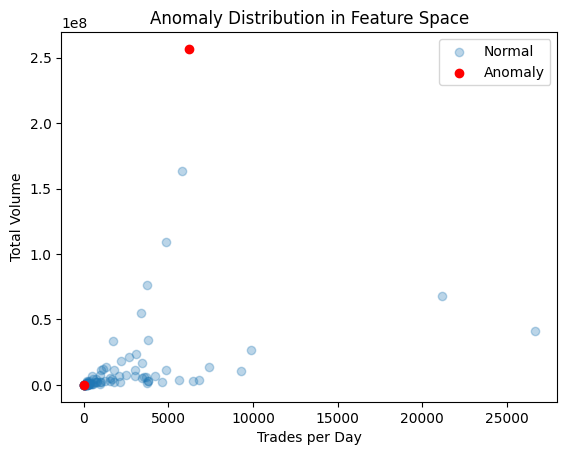

In [19]:
plt.figure()

normal = results[results["is_anomaly"] == 0]
anomaly = results[results["is_anomaly"] == 1]

plt.scatter(normal["trades_per_day"], normal["total_trade_volume_per_day"], alpha=0.3, label="Normal")
plt.scatter(anomaly["trades_per_day"], anomaly["total_trade_volume_per_day"], color="red", label="Anomaly")

plt.xlabel("Trades per Day")
plt.ylabel("Total Volume")
plt.legend()
plt.title("Anomaly Distribution in Feature Space")

plt.show()

### Interpretation

Anomalies appear in extreme regions of the feature space, particularly:

- Very high trading volume
- High trade frequency

This indicates the model captures **outliers in trading intensity**.

## Model Sensitivity: Contamination Parameter

Isolation Forest requires specifying expected anomaly proportion (`contamination`).

We test how sensitive results are to this assumption.

In [20]:
from sklearn.ensemble import IsolationForest
import numpy as np

X = results[[
    "trades_per_day",
    "total_trade_volume_per_day",
    "avg_trade_size",
    "avg_time_between_trades"
]].fillna(0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

contamination_values = [0.01, 0.02, 0.05, 0.1]
anomaly_counts = []

for c in contamination_values:
    model = IsolationForest(contamination=c, random_state=42)
    preds = model.fit_predict(X_scaled)
    preds = np.where(preds == -1, 1, 0)
    anomaly_counts.append(preds.sum())

anomaly_counts

[np.int64(2), np.int64(3), np.int64(6), np.int64(11)]

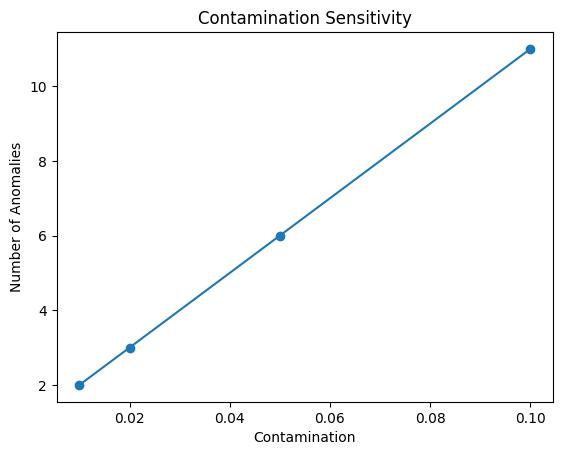

In [21]:
plt.plot(contamination_values, anomaly_counts, marker="o")
plt.xlabel("Contamination")
plt.ylabel("Number of Anomalies")
plt.title("Contamination Sensitivity")
plt.show()

### Interpretation

As expected, increasing contamination increases the number of detected anomalies.

A stable trend indicates the model behaves consistently.

This helps validate that anomaly detection is not overly sensitive to parameter choice.

## Key Insights

- Anomalies represent ~2% of user behavior
- They are characterized by:
  - High trading volume
  - Large trade sizes
  - Extreme activity levels
- Model captures global behavioral outliers effectively

## Conclusion

The model identifies a small subset (~2%) of trading behavior as anomalous.

These anomalies are characterized by:
- Significantly higher trading volumes compared to the population
- Larger average trade sizes
- In some cases, unusually high or extremely low trading frequency

This suggests that the model is primarily detecting **intensity-based outliers**, where certain accounts operate at scales far beyond typical users.

Notably:
- One anomaly exhibits extremely high volume and trade frequency, consistent with potential automated or high-frequency trading
- Another anomaly shows very low activity but abnormal temporal patterns, indicating irregular behavior

### Limitations

- The model assumes a fixed anomaly proportion (`contamination`)
- No labeled data is available to validate true anomalies
- Behavioral context (e.g., market conditions, user type) is not incorporated

### Next Steps

To improve reliability and interpretability:
- Incorporate temporal features (e.g., rolling volatility, burst patterns)
- Enrich data with user metadata (if available)
- Compare multiple models (e.g., Isolation Forest vs LOF)
- Perform manual inspection of flagged accounts

Overall, the system provides a strong baseline for detecting abnormal trading behavior, but should be combined with domain knowledge for real-world decision-making.